In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

In [2]:
df = pd.read_csv("cgpa_package.csv")
df.head()

,CGPA,Package_LPA
0,6.84,6.40
1,9.66,9.42
2,8.59,9.19
3,7.93,8.38
4,5.76,5.09


In [3]:
df.isnull().sum()

CGPA           0
Package_LPA    0
dtype: int64

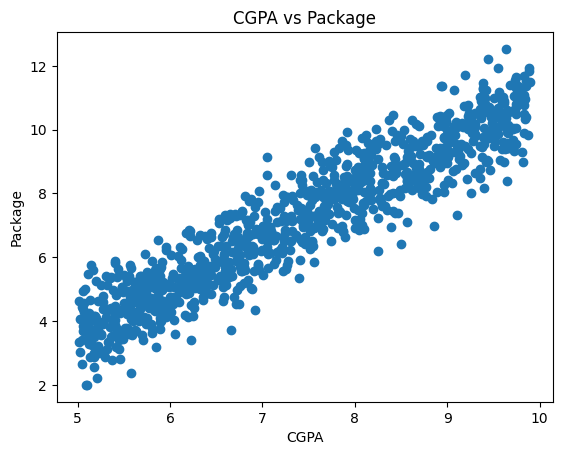

In [ ]:
plt.scatter(df["CGPA"], df["Package_LPA"])
plt.xlabel("CGPA")
plt.ylabel("Package")
plt.title("CGPA vs Package")    
plt.show()

In [6]:
X = df[["CGPA"]]   # double brackets → 2D
y = df["Package_LPA"]

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [8]:
model = LinearRegression()
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [9]:
print("Slope (w):", model.coef_[0])
print("Intercept (b):", model.intercept_)

Slope (w): 1.4711414216439545
Intercept (b): -3.7034687814785663


In [10]:
y_pred = model.predict(X_test)

In [11]:
mse = mean_squared_error(y_test, y_pred)
print("MSE:", mse)
r2 = r2_score(y_test, y_pred)
print("R2 Score:", r2)

MSE: 0.5474828305714269
R2 Score: 0.8899495552798595


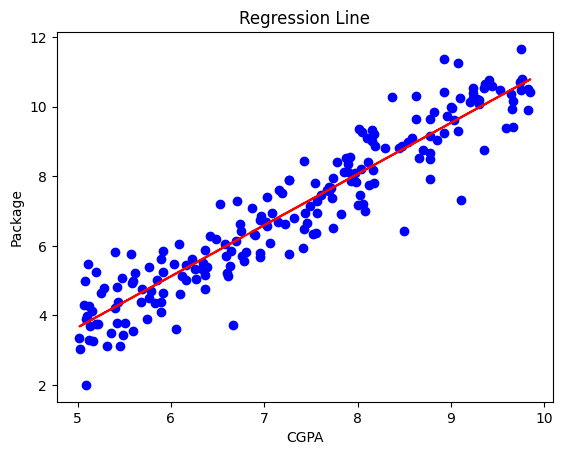

In [ ]:
plt.scatter(X_test, y_test, color="blue")
plt.plot(X_test, y_pred, color="red")
plt.xlabel("CGPA")
plt.ylabel("Package")
plt.title("Regression Line")
plt.show()